## Model Explainability
The explainability analysis will cover:

- Global feature importance
- Direction and magnitude of feature impact
- SHAP summary visualization
- Individual applicant explanations
- High-risk and low-risk prediction analysis
- Business interpretation of model behavior

##  Explainability Objectives

The primary objectives of this analysis are:

1. Identify the most influential features used by the model.
2. Understand whether each feature increases or decreases default risk.
3. Explain individual applicant predictions.
4. Identify characteristics associated with higher default risk.
5. Improve the transparency and interpretability of the credit-risk model.

In [17]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

print("Libraries imported successfully.")

Libraries imported successfully.


### Load Final optimized XGboost model

In [18]:
model = joblib.load("../models/xgboost_model.pkl")

print("Model loaded successfully.")
print("Model type:", type(model))

Model loaded successfully.
Model type: <class 'xgboost.sklearn.XGBClassifier'>


### Load Processed Test Data
- The test data contains the final transformed feature representation
used by the XGBoost model.

In [19]:
# Load processed test data

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

# Convert target DataFrame to Series
y_test = y_test.squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (51070, 24)
y_test shape: (51070,)


### Processed Features

In [20]:
# Display processed feature names

feature_names = X_test.columns.tolist()

print("Number of Features:", len(feature_names))

print("\nProcessed Features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of Features: 24

Processed Features:
1. Age
2. Income
3. LoanAmount
4. CreditScore
5. MonthsEmployed
6. NumCreditLines
7. InterestRate
8. LoanTerm
9. DTIRatio
10. Education_High School
11. Education_Master's
12. Education_PhD
13. EmploymentType_Part-time
14. EmploymentType_Self-employed
15. EmploymentType_Unemployed
16. MaritalStatus_Married
17. MaritalStatus_Single
18. HasMortgage_Yes
19. HasDependents_Yes
20. LoanPurpose_Business
21. LoanPurpose_Education
22. LoanPurpose_Home
23. LoanPurpose_Other
24. HasCoSigner_Yes


In [21]:
# Verify that model and test data have matching feature dimensions

print("Model expected features:", model.n_features_in_)
print("Test dataset features:", X_test.shape[1])

if model.n_features_in_ == X_test.shape[1]:
    print("\n Feature dimensions match.")
else:
    print("\n Feature dimension mismatch.")

Model expected features: 24
Test dataset features: 24

 Feature dimensions match.


## SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to interpret the predictions
of the optimized XGBoost model.

SHAP assigns each feature a contribution value that indicates how strongly
that feature influenced a prediction.

Positive SHAP values generally push the prediction toward the Default
class, while negative values push the prediction toward the Non-Default
class.

In [22]:
import sys
import numpy
import numba
import llvmlite

print("Python   :", sys.version)
print("NumPy    :", numpy.__version__)
print("Numba    :", numba.__version__)
print("llvmlite :", llvmlite.__version__)

Python   : 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
NumPy    : 2.4.6
Numba    : 0.66.0
llvmlite : 0.48.0


In [23]:
import shap

print("SHAP:", shap.__version__)

SHAP: 0.52.0


##  Create SHAP Tree Explainer

Because the final model is an XGBoost tree-based model, SHAP's
TreeExplainer is used to efficiently calculate feature contributions.

To make the analysis computationally efficient, a representative sample
of the test dataset is used for the global explainability analysis.

In [27]:
# Create SHAP TreeExplainer

explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [28]:
# Create SHAP TreeExplainer

explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


## Calculate SHAP Values

SHAP values quantify the contribution of each feature to the model's
prediction.

These values will be used to identify the most influential factors in
the model's default-risk predictions.

In [29]:
# Calculate SHAP values

shap_values = explainer.shap_values(shap_sample)

print("SHAP values calculated successfully.")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values calculated successfully.
SHAP values shape: (5000, 24)


### Global Feature Importance 

Global feature importance identifies the features that have the greatest
overall influence on the model's predictions.


In [30]:
# Calculate mean absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_ABS_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean_ABS_SHAP", ascending=False)
    .reset_index(drop=True)
)

shap_importance

,Feature,Mean_ABS_SHAP
0,Age,0.540104
1,InterestRate,0.416475
2,MonthsEmployed,0.311380
3,Income,0.282891
4,LoanAmount,0.262005
5,HasCoSigner_Yes,0.125452
6,HasDependents_Yes,0.124428
7,CreditScore,0.119443
8,EmploymentType_Unemployed,0.109617
9,NumCreditLines,0.103015


### Top Features by SHAP Importance

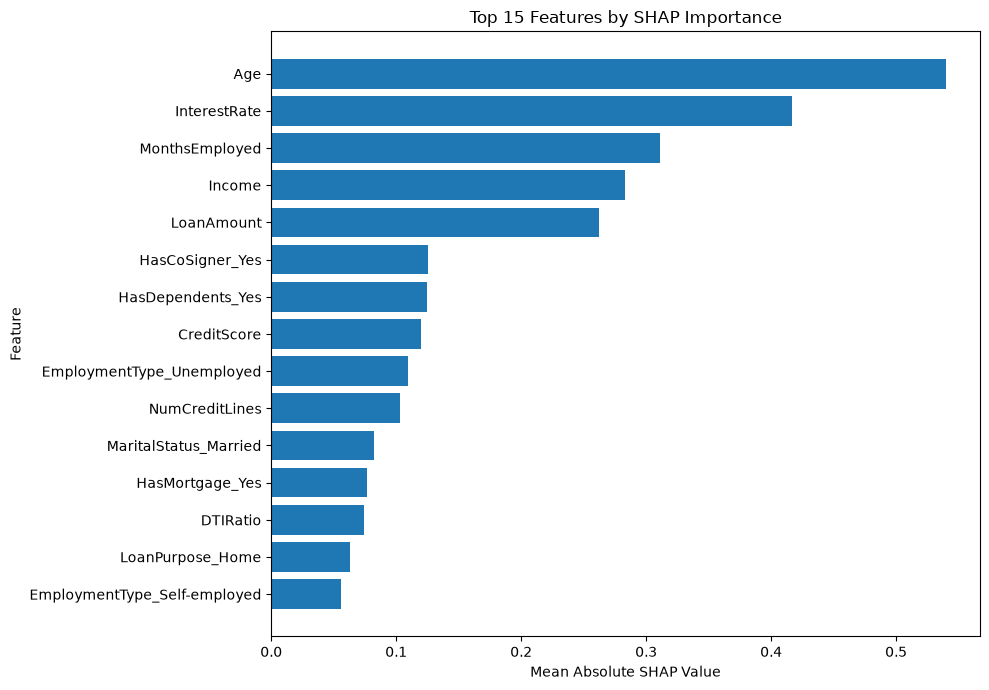

In [31]:
# Plot top 15 features

top_features = shap_importance.head(15).sort_values(
    "Mean_ABS_SHAP",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean_ABS_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features by SHAP Importance"
)

plt.tight_layout()
plt.show()

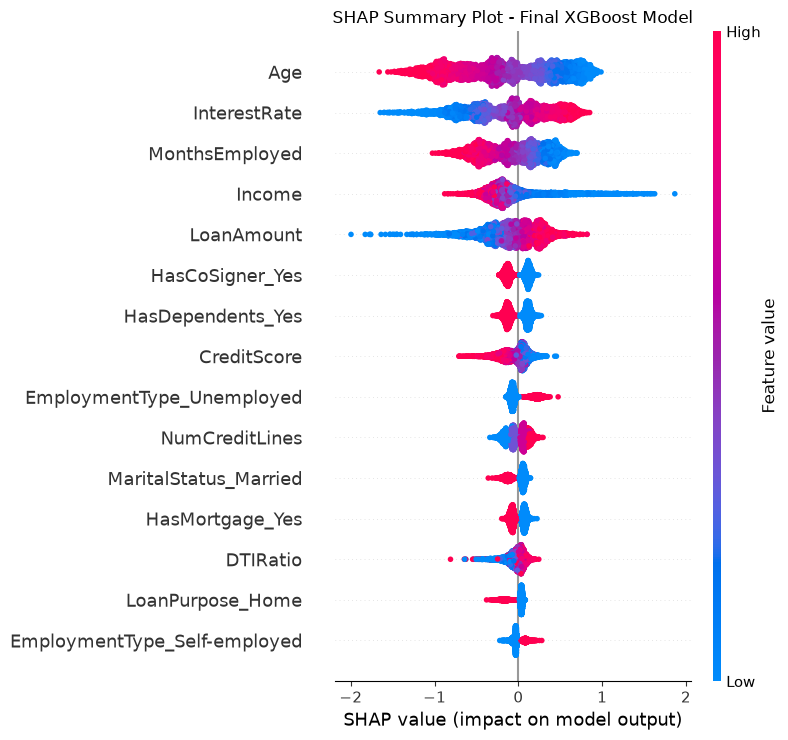

In [32]:
# SHAP summary / beeswarm plot

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot - Final XGBoost Model"
)

plt.tight_layout()
plt.show()